In [1]:
from scipy.stats import qmc
import torch
import numpy as np

# 1. Generate and scale 2D LHS points
sampler = qmc.LatinHypercube(d=2)
raw_samples = sampler.random(n=2500)
# lb = [x_min, t_min], ub = [x_max, t_max]
scaled = qmc.scale(raw_samples, l_bounds=[-1.0, 0.0], u_bounds=[1.0, 1.0])


# 2. Convert to PyTorch tensors with shape (N, 1) and enable autograd
x_f = torch.tensor(scaled[:, 0:1], dtype=torch.float32, requires_grad=True)
t_f = torch.tensor(scaled[:, 1:2], dtype=torch.float32, requires_grad=True)

#boundary
sampler_1d = qmc.LatinHypercube(d=1)
t_samples = qmc.scale(sampler_1d.random(n=100), 0, 1.0)
t_b = torch.tensor(t_samples, dtype=torch.float32)

x_left = -1.0 * torch.ones(50, 1, dtype=torch.float32)
x_right = 1.0 * torch.ones(50, 1, dtype=torch.float32)
x_b = torch.vstack([x_left, x_right])
u_b = torch.zeros(x_b.shape)

#initial
sampler_1d = qmc.LatinHypercube(d=1)
x_samples = qmc.scale(sampler_1d.random(n=100), -1.0, 1.0)
t_in = torch.zeros(100, 1, dtype=torch.float32)
x_in = torch.tensor(x_samples, dtype=torch.float32)
u_in = -torch.sin(torch.pi *x_in)


In [2]:
from math import tanh
import torch.nn as nn

class BurgersPINN(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.net = nn.Sequential(
    nn.Linear(2, 50),
    nn.Tanh(),
    nn.Linear(50, 50),
    nn.Tanh(),
    nn.Linear(50, 50),
    nn.Tanh(),
    nn.Linear(50, 50),
    nn.Tanh(),
    nn.Linear(50, 1)
)

  def forward(self, x, t):
    X = torch.cat([x, t], dim=1)
    return self.net(X)

model = BurgersPINN()

In [3]:
u_test = model(x_f, t_f)
print("Output shape:", u_test.shape)
print("Total parameters:", sum(p.numel() for p in model.parameters()))

Output shape: torch.Size([2500, 1])
Total parameters: 7851


In [4]:
def compute_pde_residual(model, x, t, nu):
  u = model(x, t);
  u_t = torch.autograd.grad(
    outputs=u,
    inputs=t,
    grad_outputs=torch.ones_like(u),
    create_graph=True
  )[0]
  u_x = torch.autograd.grad(
    outputs=u,
    inputs=x,
    grad_outputs=torch.ones_like(u),
    create_graph=True
  )[0]
  u_xx = torch.autograd.grad(
    outputs=u_x,
    inputs=x,
    grad_outputs=torch.ones_like(u_x),
    create_graph=True
  )[0]

  R = u_t + u*u_x - nu * u_xx;

  return R

In [5]:
def compute_loss(model, x_in, t_in, u_in, x_b, t_b, u_b, x_f, t_f, nu):
  u_in_p=model(x_in, t_in)
  u_b_p=model(x_b, t_b)
  R = compute_pde_residual(model, x_f, t_f, nu)
  loss_ic = torch.mean((u_in_p - u_in)**2)
  loss_bc = torch.mean((u_b_p - u_b)**2)
  loss_pde = torch.mean(R**2)

  total_loss = 50*loss_ic + 10*loss_bc + loss_pde

  return total_loss, loss_ic, loss_bc, loss_pde

In [6]:
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
nu=0.01 / torch.pi
for epoch in range(2000):
    optimizer_adam.zero_grad()
    loss, loss_ic, loss_bc, loss_pde = compute_loss(model, x_in, t_in, u_in, x_b, t_b, u_b, x_f, t_f, nu)
    loss.backward()
    optimizer_adam.step()

    if epoch % 200 == 0:
        print(f"Adam Epoch {epoch} | Total: {loss.item():.4e} | PDE: {loss_pde.item():.4e}")

Adam Epoch 0 | Total: 2.5086e+01 | PDE: 4.8243e-04
Adam Epoch 200 | Total: 5.5520e-01 | PDE: 4.0319e-01
Adam Epoch 400 | Total: 4.4456e-01 | PDE: 3.7378e-01
Adam Epoch 600 | Total: 3.6543e-01 | PDE: 3.3415e-01
Adam Epoch 800 | Total: 3.2459e-01 | PDE: 3.0466e-01
Adam Epoch 1000 | Total: 3.1568e-01 | PDE: 2.7901e-01
Adam Epoch 1200 | Total: 2.9343e-01 | PDE: 2.7817e-01
Adam Epoch 1400 | Total: 2.8617e-01 | PDE: 2.7165e-01
Adam Epoch 1600 | Total: 2.8246e-01 | PDE: 2.6114e-01
Adam Epoch 1800 | Total: 2.7553e-01 | PDE: 2.5975e-01


In [7]:
def closure():
    optimizer_lbfgs.zero_grad()
    loss, loss_ic, loss_bc, loss_pde= compute_loss(model, x_in, t_in, u_in, x_b, t_b, u_b, x_f, t_f, nu)
    loss.backward()
    return loss




In [8]:
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    max_iter=1000,
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    history_size=50
)

# A single call drives the entire quasi-Newton optimization
optimizer_lbfgs.step(closure)

tensor(0.2687, grad_fn=<AddBackward0>)

In [9]:
# Evaluates the converged loss without updating weights (no .backward() call)
post_loss, post_ic, post_bc, post_pde = compute_loss(
    model, x_in, t_in, u_in, x_b, t_b, u_b, x_f, t_f, nu
)

print(f"Post L-BFGS | Total: {post_loss.item():.4e} | IC: {post_ic.item():.4e} | BC: {post_bc.item():.4e} | PDE: {post_pde.item():.4e}")

Post L-BFGS | Total: 1.0016e-03 | IC: 1.7706e-06 | BC: 1.1877e-06 | PDE: 9.0117e-04


In [10]:
import numpy as np

# Create dense regular grid for evaluation
x_grid = np.linspace(-1.0, 1.0, 256)
t_grid = np.linspace(0.0, 1.0, 100)
X, T = np.meshgrid(x_grid, t_grid)

# Flatten to column vectors (N, 1)
x_eval = torch.tensor(X.flatten()[:, None], dtype=torch.float32)
t_eval = torch.tensor(T.flatten()[:, None], dtype=torch.float32)

# torch.no_grad() is safe here because we only need the scalar field u(x, t), not derivatives
with torch.no_grad():
    u_pred = model(x_eval, t_eval).numpy().reshape(X.shape)

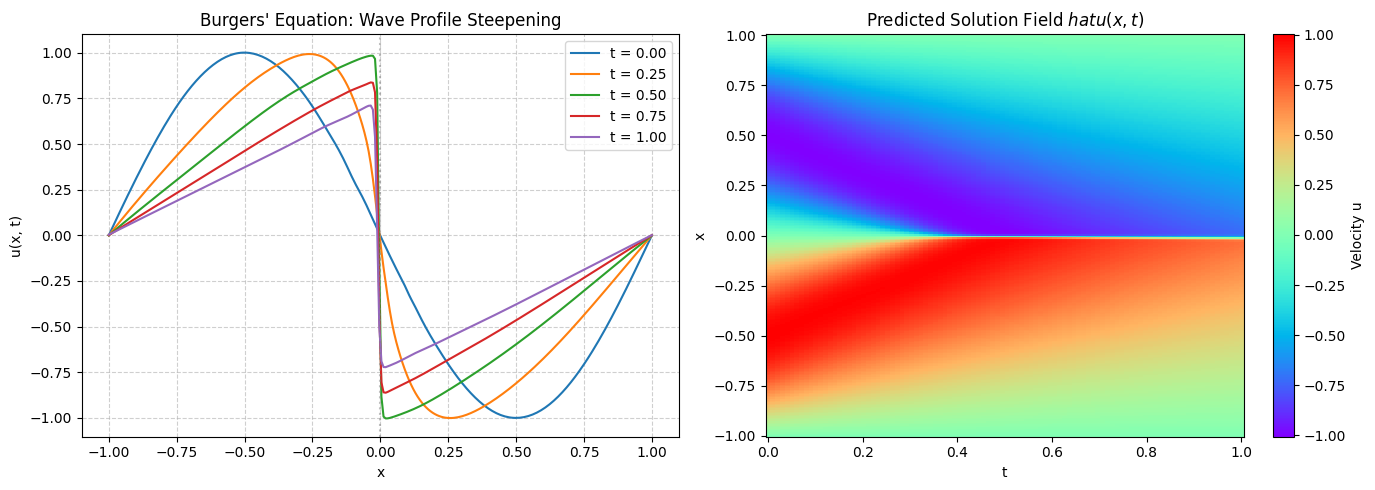

In [11]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Temporal Evolution Slices
t_snapshots = [0.0, 0.25, 0.50, 0.75, 1.0]
for t_val in t_snapshots:
    t_idx = int(t_val * (len(t_grid) - 1))
    ax1.plot(x_grid, u_pred[t_idx, :], label=f"t = {t_val:.2f}", linewidth=1.5)

ax1.set_title("Burgers' Equation: Wave Profile Steepening")
ax1.set_xlabel("x")
ax1.set_ylabel("u(x, t)")
ax1.axvline(0, color="gray", linestyle=":", alpha=0.5)
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# 2. Space-Time Heatmap
mesh = ax2.pcolormesh(T, X, u_pred, cmap="rainbow", shading="auto")
ax2.set_title("Predicted Solution Field $hat{u}(x, t)$")
ax2.set_xlabel("t")
ax2.set_ylabel("x")
fig.colorbar(mesh, ax=ax2, label="Velocity u")

plt.tight_layout()
plt.show()

In [12]:
# Sample unseen future points outside the training cylinder
sampler_ext = qmc.LatinHypercube(d=2)
scaled_ext = qmc.scale(sampler_ext.random(n=1000), l_bounds=[-1.0, 1.0], u_bounds=[1.0, 1.3])

x_ext = torch.tensor(scaled_ext[:, 0:1], dtype=torch.float32, requires_grad=True)
t_ext = torch.tensor(scaled_ext[:, 1:2], dtype=torch.float32, requires_grad=True)

# PDE residual requires autograd enabled
res_ext = compute_pde_residual(model, x_ext, t_ext, nu)
loss_pde_ext = torch.mean(res_ext**2).item()

print(f"In-Domain PDE Residual (t <= 1.0):     {post_pde.item():.4e}")
print(f"Extrapolation PDE Residual (t > 1.0):  {loss_pde_ext:.4e}")

In-Domain PDE Residual (t <= 1.0):     9.0117e-04
Extrapolation PDE Residual (t > 1.0):  8.9215e-02


In [15]:
import urllib.request
import scipy.io
import numpy as np
import torch
import matplotlib.pyplot as plt

# Notice the uppercase 'Data'
url = "https://github.com/maziarraissi/PINNs/raw/master/appendix/Data/burgers_shock.mat"
urllib.request.urlretrieve(url, "burgers_shock.mat")

# Load benchmark matrices
data = scipy.io.loadmat("burgers_shock.mat")
x_exact = data["x"].flatten()        # Shape: (256,) in [-1, 1]
t_exact = data["t"].flatten()        # Shape: (100,) in [0, 1]
u_exact = np.real(data["usol"])      # Shape: (256, 100)

print(f"Successfully loaded ground truth. Matrix shape: {u_exact.shape}")

Successfully loaded ground truth. Matrix shape: (256, 100)


<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_2581/1184861739.py:18: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(x_exact, u_pred_ref[:, -1], "r-", linewidth=1.5, label="PINN Prediction ($\hat{u}$)")


Overall Relative L2 Error: 7.6429e-02 (7.64%)


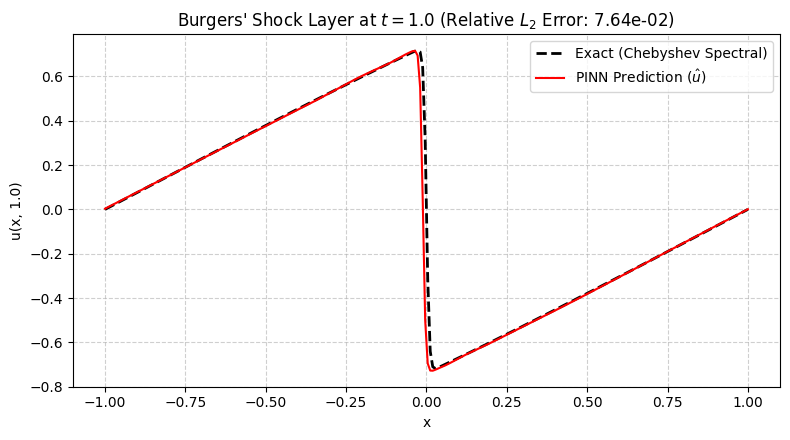

In [16]:
# 1. Meshgrid matching reference matrix
X_ref, T_ref = np.meshgrid(x_exact, t_exact)  # Both shape: (100, 256)

x_ref_flat = torch.tensor(X_ref.flatten()[:, None], dtype=torch.float32)
t_ref_flat = torch.tensor(T_ref.flatten()[:, None], dtype=torch.float32)

# 2. Evaluate model
with torch.no_grad():
    u_pred_ref = model(x_ref_flat, t_ref_flat).numpy().reshape(100, 256).T

# 3. Overall Relative L2 Error
l2_error = np.linalg.norm(u_exact - u_pred_ref, 2) / np.linalg.norm(u_exact, 2)
print(f"Overall Relative L2 Error: {l2_error:.4e} ({l2_error * 100:.2f}%)")

# 4. Parity Plot at t = 1.0 (The Shock Profile)
plt.figure(figsize=(8, 4.5))
plt.plot(x_exact, u_exact[:, -1], "k--", linewidth=2.0, label="Exact (Chebyshev Spectral)")
plt.plot(x_exact, u_pred_ref[:, -1], "r-", linewidth=1.5, label="PINN Prediction ($\hat{u}$)")
plt.title(f"Burgers' Shock Layer at $t = 1.0$ (Relative $L_2$ Error: {l2_error:.2e})")
plt.xlabel("x")
plt.ylabel("u(x, 1.0)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()